In [63]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

 - https://stackoverflow.com/questions/27727762/scipy-generate-random-variables-with-correlations

In [4]:
mu = np.array([1, 2, 3])
cov = np.array([
    [1, 0.1, 0.5],
    [0.1, 4, 0.8],
    [0.5, 0.8, 9],
])

In [9]:
X = np.random.multivariate_normal(mu, cov, 5000)
X.shape

(5000, 3)

In [10]:
np.cov(X.T)

array([[0.98898067, 0.03154116, 0.49110734],
       [0.03154116, 4.0807209 , 0.69828235],
       [0.49110734, 0.69828235, 9.05151889]])

In [52]:
def cdf(X):
    y = []
    for x in X.T:
        p = stats.norm.fit(x)
        law = stats.norm(*p)
        y.append(law.cdf(x))
    return np.array(y).T

In [53]:
def ppf(Y, laws=None):
    if laws is None:
        laws = [stats.norm] * Y.shape[1]
    z = []
    for y, law in zip(Y.T, laws):
        z.append(law.ppf(y))
    return np.array(z).T

In [54]:
X

array([[ 1.22431641, -2.35345213, -4.41877977],
       [ 0.72467608,  4.48724849,  2.56104595],
       [-1.05575778,  2.09064751,  4.39370239],
       ...,
       [ 0.68418562,  6.84584421,  4.26591083],
       [ 0.98161217, -0.26227679,  0.55156743],
       [-0.10846793,  6.06357367,  2.94671408]])

In [61]:
Z = ppf(cdf(X), [stats.lognorm(0.8), stats.norm(), stats.beta(1.1, 0.9)])
Z

array([[ 1.1877909 , -2.18616208,  0.01161416],
       [ 0.79463061,  1.2005289 ,  0.50755262],
       [ 0.18970569,  0.01402077,  0.7362399 ],
       ...,
       [ 0.76916213,  2.36822141,  0.72203163],
       [ 0.97709986, -1.15086394,  0.25881586],
       [ 0.40650337,  1.98093526,  0.55861627]])

In [62]:
np.cov(Z.T)

array([[1.74890218, 0.02657651, 0.05164487],
       [0.02657651, 1.00020004, 0.03194837],
       [0.05164487, 0.03194837, 0.08273561]])

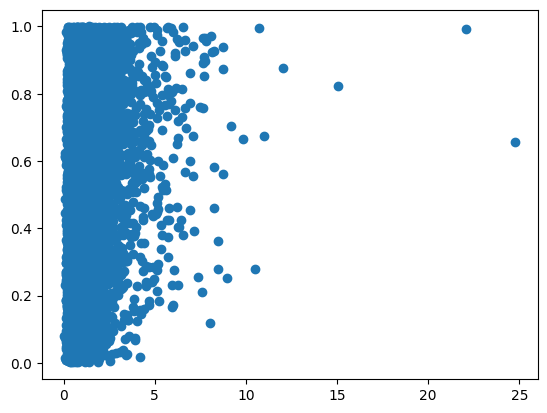

In [66]:
fig, axe = plt.subplots()
axe.scatter(Z[:,0], Z[:,2])